# Lab02 - Linear Regression Report
**Ogrenci:** Halil Ibrahim Kutmur  
**Numara:** 24458667010  
**Tarih:** 02.04.2026

Bu notebook, CarSales veri seti uzerinde basit ve coklu dogrusal regresyon uygulamasini gosterir.
Ayrica ogrenme katsayisinin (learning rate) gradyan inisi davranisina etkisi grafiklerle incelenir.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")

In [16]:
# loading the csv data to a Pandas DataFrame
car_data = pd.read_csv('data/car.csv')

In [17]:
# print firs 5 rows of the dataset
car_data.head()

,Manufacturer,Model,Sales_in_thousand,Year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [18]:
# print last 5 rows of the dataset
car_data.tail()

,Manufacturer,Model,Sales_in_thousand,Year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
152,Volvo,V40,3.545,NaN,Passenger,24.4,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,Volvo,S70,15.245,NaN,Passenger,27.5,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,Volvo,V70,17.531,NaN,Passenger,28.8,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,Volvo,C70,3.493,NaN,Passenger,45.5,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357
156,Volvo,S80,18.969,NaN,Passenger,36.0,2.9,201.0,109.9,72.1,189.8,3.600,21.1,24.0,11/14/2011,85.735655


In [19]:
# number of rows and columns in the dataset
car_data.shape

(157, 16)

In [20]:
# getting some info about the data
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manufacturer        157 non-null    object 
 1   Model               157 non-null    object 
 2   Sales_in_thousand   157 non-null    float64
 3   Year_resale_value   121 non-null    float64
 4   Vehicle_type        157 non-null    object 
 5   Price_in_thousands  155 non-null    float64
 6   Engine_size         156 non-null    float64
 7   Horsepower          156 non-null    float64
 8   Wheelbase           156 non-null    float64
 9   Width               156 non-null    float64
 10  Length              156 non-null    float64
 11  Curb_weight         155 non-null    float64
 12  Fuel_capacity       156 non-null    float64
 13  Fuel_efficiency     154 non-null    float64
 14  Latest_Launch       157 non-null    object 
 15  Power_perf_factor   155 non-null    float64
dtypes: float

In [21]:
# checking for missing values
car_data.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousand      0
Year_resale_value     36
Vehicle_type           0
Price_in_thousands     2
Engine_size            1
Horsepower             1
Wheelbase              1
Width                  1
Length                 1
Curb_weight            2
Fuel_capacity          1
Fuel_efficiency        3
Latest_Launch          0
Power_perf_factor      2
dtype: int64

In [22]:
# statistical measures about the data
car_data.describe()

,Sales_in_thousand,Year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


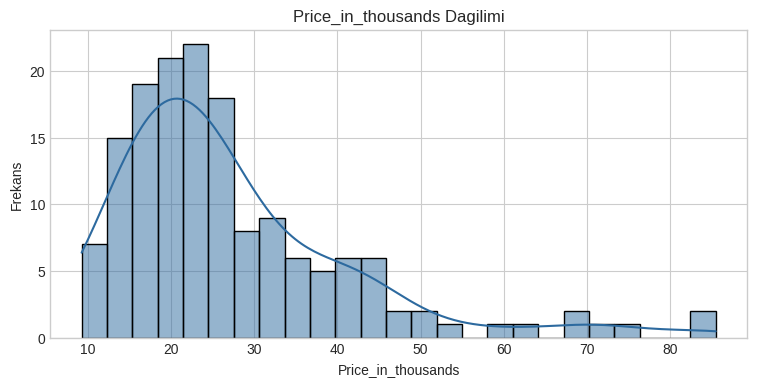

In [23]:
# checking the distribution of Price_in_thousands Variable
plt.figure(figsize=(9, 4))
sns.histplot(car_data["Price_in_thousands"].dropna(), bins=25, kde=True, color="#2D6A9F")
plt.title("Price_in_thousands Dagilimi")
plt.xlabel("Price_in_thousands")
plt.ylabel("Frekans")
plt.show()

In [ ]:
# fill missing values
df = car_data.copy()

numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(exclude=["number"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sort_values(ascending=False).head(10)

Manufacturer          0
Model                 0
Sales_in_thousand     0
Year_resale_value     0
Vehicle_type          0
Price_in_thousands    0
Engine_size           0
Horsepower            0
Wheelbase             0
Width                 0
dtype: int64

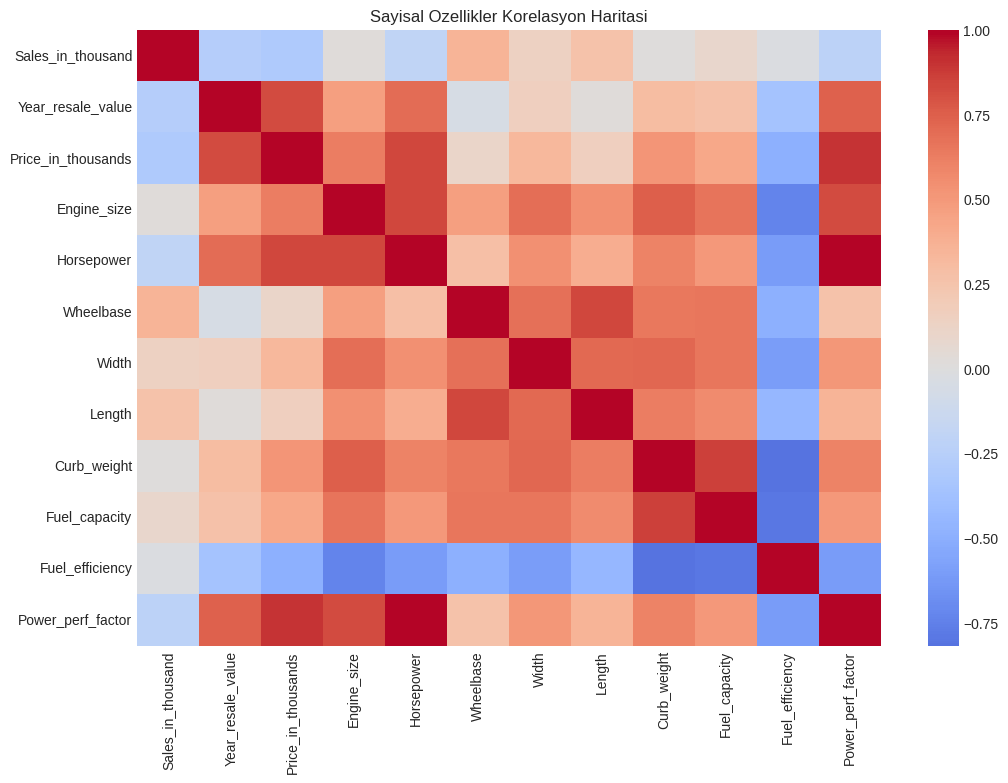

Power_perf_factor    0.897945
Horsepower           0.838450
Year_resale_value    0.822395
Engine_size          0.626839
Curb_weight          0.523753
Fuel_efficiency     -0.491489
Fuel_capacity        0.423230
Width                0.329109
Sales_in_thousand   -0.304413
Length               0.156874
Name: Price_in_thousands, dtype: float64

In [25]:
# corelation map of all the features
numeric_df = df.select_dtypes(include=["number"]).copy()
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Sayisal Ozellikler Korelasyon Haritasi")
plt.show()

target_col = "Price_in_thousands"
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
target_corr.head(10)

In [26]:
# translate string values to numeric representations
encoded_df = pd.get_dummies(df, drop_first=True)

print(f"Orijinal boyut: {df.shape}")
print(f"Encode sonrasi boyut: {encoded_df.shape}")
encoded_df.head(3)

Orijinal boyut: (157, 16)
Encode sonrasi boyut: (157, 326)


,Sales_in_thousand,Year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Latest_Launch_9/1/2011,Latest_Launch_9/10/2012,Latest_Launch_9/11/2011,Latest_Launch_9/14/2012,Latest_Launch_9/21/2011,Latest_Launch_9/22/2012,Latest_Launch_9/25/2011,Latest_Launch_9/26/2011,Latest_Launch_9/28/2011,Latest_Launch_9/3/2011
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,False
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,False
2,14.114,18.225,27.390755,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,False


## A) Basit Dogrusal Regresyon
Bu bolumde hedef degisken ile mutlak korelasyonu en yuksek tek bagimsiz degisken secilerek fiyat tahmini yapilir.
Asagidaki loss grafiginde farkli ogrenme katsayilarinin gradyan inisi hizina etkisi gozlemlenir.

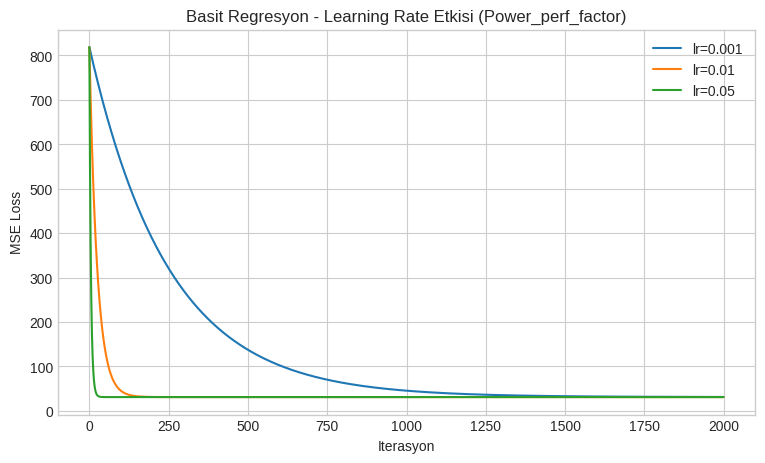

Secilen ozellik: Power_perf_factor
Mutlak korelasyon: 0.8979
En iyi learning rate (train loss'a gore): 0.01
MAE: 5.7776
RMSE: 8.8039
R2: 0.7744


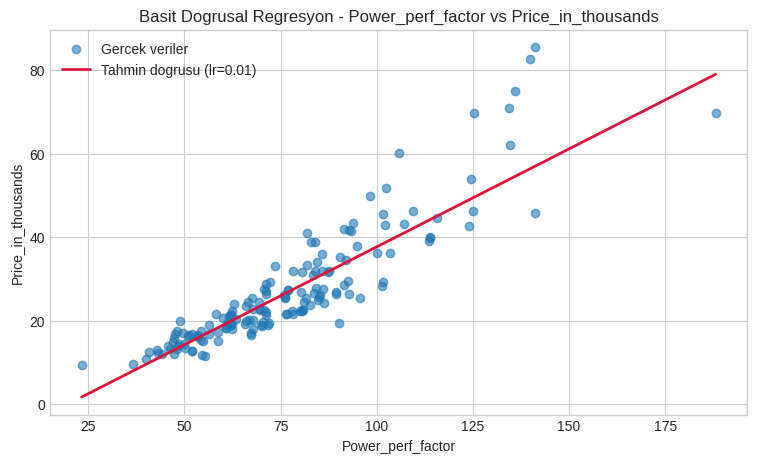

sklearn R2: 0.7744


In [27]:
# basic lineer regression using 1 features that effect the most
target_col = "Price_in_thousands"
numeric_corr = df.select_dtypes(include=["number"]).corr()[target_col].drop(target_col)
best_feature = numeric_corr.abs().idxmax()

X_simple = df[[best_feature]].values.astype(float)
y_simple = df[target_col].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0)
x_std[x_std == 0] = 1.0

X_train_std = (X_train - x_mean) / x_std
X_test_std = (X_test - x_mean) / x_std

def gradient_descent_simple(X, y, lr=0.01, epochs=2000):
    m = X.shape[0]
    w = 0.0
    b = 0.0
    losses = []

    x_flat = X[:, 0]
    for _ in range(epochs):
        y_pred = w * x_flat + b
        error = y_pred - y
        losses.append(np.mean(error ** 2))

        dw = (2 / m) * np.dot(error, x_flat)
        db = (2 / m) * np.sum(error)

        w -= lr * dw
        b -= lr * db

    return w, b, losses

learning_rates = [0.001, 0.01, 0.05]
simple_runs = {}
for lr in learning_rates:
    w_lr, b_lr, losses_lr = gradient_descent_simple(X_train_std, y_train, lr=lr, epochs=2000)
    simple_runs[lr] = {"w": w_lr, "b": b_lr, "losses": losses_lr}

plt.figure(figsize=(9, 5))
for lr, run in simple_runs.items():
    plt.plot(run["losses"], label=f"lr={lr}")
plt.title(f"Basit Regresyon - Learning Rate Etkisi ({best_feature})")
plt.xlabel("Iterasyon")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

best_lr_simple = min(simple_runs, key=lambda lr: simple_runs[lr]["losses"][-1])
w_simple = simple_runs[best_lr_simple]["w"]
b_simple = simple_runs[best_lr_simple]["b"]

y_test_pred_simple = w_simple * X_test_std[:, 0] + b_simple

print(f"Secilen ozellik: {best_feature}")
print(f"Mutlak korelasyon: {abs(numeric_corr[best_feature]):.4f}")
print(f"En iyi learning rate (train loss'a gore): {best_lr_simple}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred_simple):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_simple)):.4f}")
print(f"R2: {r2_score(y_test, y_test_pred_simple):.4f}")

X_all_std = (X_simple - x_mean) / x_std
y_all_pred = w_simple * X_all_std[:, 0] + b_simple
sorted_idx = np.argsort(X_simple[:, 0])

plt.figure(figsize=(9, 5))
plt.scatter(X_simple[:, 0], y_simple, alpha=0.6, label="Gercek veriler")
plt.plot(
    X_simple[sorted_idx, 0],
    y_all_pred[sorted_idx],
    color="crimson",
    linewidth=2,
    label=f"Tahmin dogrusu (lr={best_lr_simple})",
)
plt.title(f"Basit Dogrusal Regresyon - {best_feature} vs {target_col}")
plt.xlabel(best_feature)
plt.ylabel(target_col)
plt.legend()
plt.show()

# sklearn ile hizli referans
sk_simple = LinearRegression()
sk_simple.fit(X_train, y_train)
sk_pred_simple = sk_simple.predict(X_test)
print(f"sklearn R2: {r2_score(y_test, sk_pred_simple):.4f}")

## B) Coklu Dogrusal Regresyon
Bu bolumde hedef degisken ile mutlak korelasyonu en yuksek en az 2 degisken secilir.
Farkli ogrenme katsayilari ile modelin yakinlama davranisi ve test basarimi karsilastirilir.

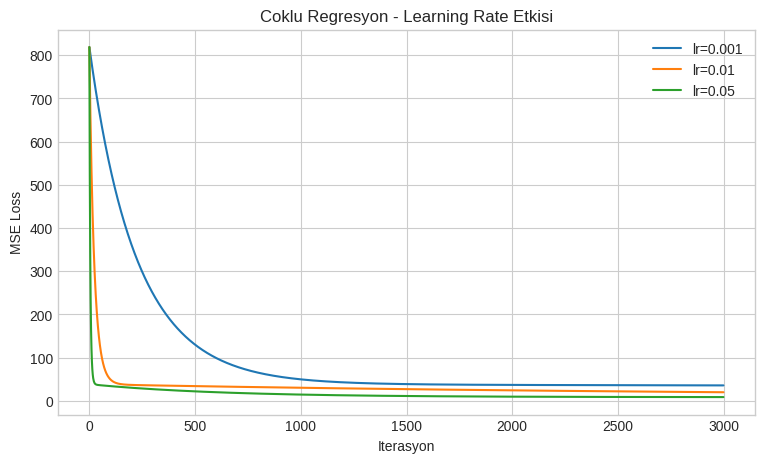

Secilen ozellikler ve korelasyonlari:
- Power_perf_factor: 0.8979
- Horsepower: 0.8384
En iyi learning rate (train loss'a gore): 0.05
MAE: 1.9864
RMSE: 2.9887
R2: 0.9740


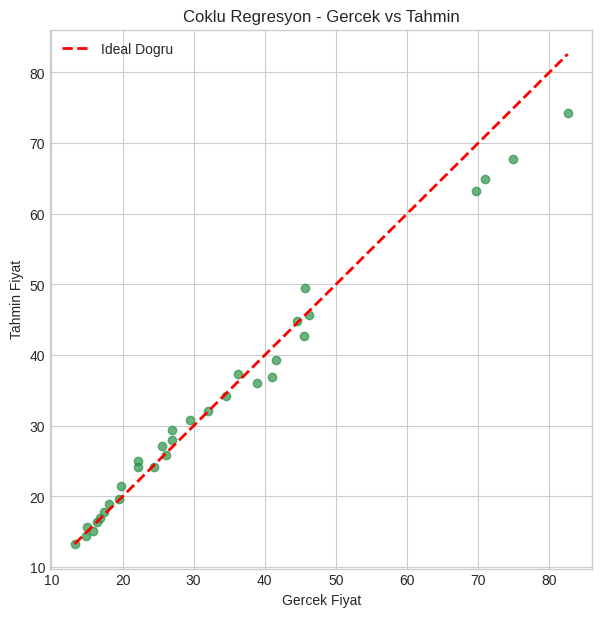

sklearn RMSE: 2.3118
sklearn R2: 0.9844


In [28]:
# multi lineer regression using 2 features that effect the most
top_features = numeric_corr.abs().sort_values(ascending=False).head(2).index.tolist()

X_multi = df[top_features].values.astype(float)
y_multi = df[target_col].values.astype(float)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

mu = X_train_m.mean(axis=0)
sigma = X_train_m.std(axis=0)
sigma[sigma == 0] = 1.0

X_train_m_std = (X_train_m - mu) / sigma
X_test_m_std = (X_test_m - mu) / sigma

def gradient_descent_multi(X, y, lr=0.01, epochs=3000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    losses = []

    for _ in range(epochs):
        y_pred = X @ w + b
        error = y_pred - y
        losses.append(np.mean(error ** 2))

        dw = (2 / m) * (X.T @ error)
        db = (2 / m) * np.sum(error)

        w -= lr * dw
        b -= lr * db

    return w, b, losses

learning_rates_multi = [0.001, 0.01, 0.05]
multi_runs = {}
for lr in learning_rates_multi:
    w_lr, b_lr, losses_lr = gradient_descent_multi(
        X_train_m_std, y_train_m, lr=lr, epochs=3000
    )
    multi_runs[lr] = {"w": w_lr, "b": b_lr, "losses": losses_lr}

plt.figure(figsize=(9, 5))
for lr, run in multi_runs.items():
    plt.plot(run["losses"], label=f"lr={lr}")
plt.title("Coklu Regresyon - Learning Rate Etkisi")
plt.xlabel("Iterasyon")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

best_lr_multi = min(multi_runs, key=lambda lr: multi_runs[lr]["losses"][-1])
w_multi = multi_runs[best_lr_multi]["w"]
b_multi = multi_runs[best_lr_multi]["b"]
y_pred_multi = X_test_m_std @ w_multi + b_multi

print("Secilen ozellikler ve korelasyonlari:")
for feature in top_features:
    print(f"- {feature}: {numeric_corr[feature]:.4f}")
print(f"En iyi learning rate (train loss'a gore): {best_lr_multi}")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_multi):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_multi)):.4f}")
print(f"R2: {r2_score(y_test_m, y_pred_multi):.4f}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test_m, y_pred_multi, alpha=0.7, color="#2B9348")
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    "r--",
    linewidth=2,
    label="Ideal Dogru",
)
plt.xlabel("Gercek Fiyat")
plt.ylabel("Tahmin Fiyat")
plt.title("Coklu Regresyon - Gercek vs Tahmin")
plt.legend()
plt.show()

coef_df = pd.DataFrame({
    "Feature": top_features,
    "Coefficient(standardized)": w_multi,
})
coef_df

# sklearn ile hizli referans
sk_multi = LinearRegression()
sk_multi.fit(X_train_m, y_train_m)
sk_pred_multi = sk_multi.predict(X_test_m)
print(f"sklearn RMSE: {np.sqrt(mean_squared_error(y_test_m, sk_pred_multi)):.4f}")
print(f"sklearn R2: {r2_score(y_test_m, sk_pred_multi):.4f}")